In [1]:
# %load_ext autoreload
# %autoreload 2
import os, sys

import scanpy as sc
import anndata as ad
import numpy as np

import torch
from torch import nn
from matplotlib import pyplot as plt
from torch.utils.data import DataLoader

In [6]:
from scipy.special import expit, log_

In [2]:
# the data path
main_dir = '/home/wergillius/Project/diffuse_differentiate/'
data_dir = '/home/wergillius/Project/diffuse_differentiate/data/Fetal_reference/'

In [3]:
control_cb = 'R1.90,R2.33,R3.69,P1.22-0-1'

In [4]:
adata_diff = sc.read_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")

<Axes: ylabel='Frequency'>

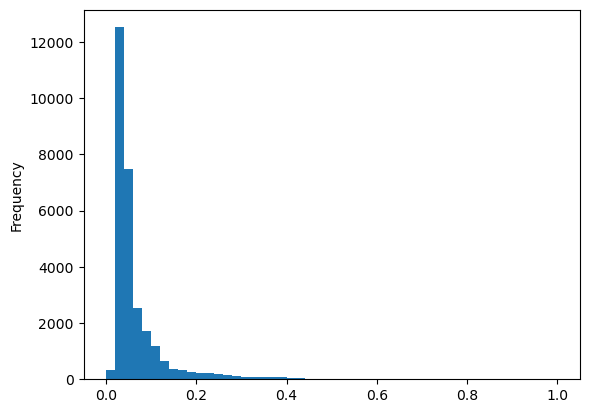

In [10]:
adata_diff.obs.dpt_pseudotime.plot(kind='hist', bins=50)

In [8]:
np.where(adata_diff.obs_names == control_cb)

(array([12980]),)

In [24]:
adata_diff.uns['iroot'] = 12980
sc.tl.diffmap(adata_diff,n_comps = 10)
sc.tl.dpt(adata_diff)

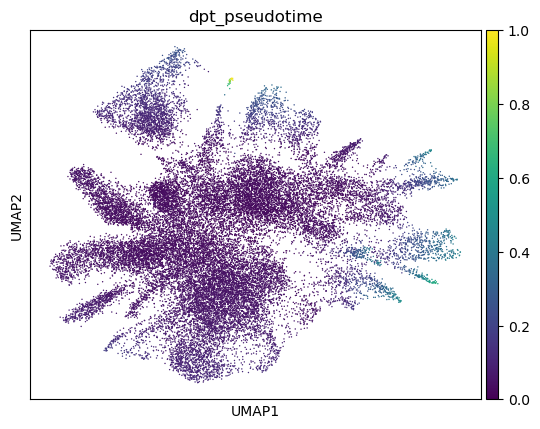

In [25]:
sc.pl.umap(adata_diff, color=['dpt_pseudotime'])

In [28]:
def discrete_time(x):
    x = int(x*250)
    mid_err = np.random.randint(-2,2) # smooth the time
    tail_err = np.random.randint(0,10)
    return min(x, 200-tail_err)

In [29]:
adata_diff.obs['discrete_time'] = adata_diff.obs['dpt_pseudotime']

In [30]:
adata_diff

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'diffmap_evals', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap', 'unique_token_dict'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

# filter TF

In [8]:
TF_sum  = adata_diff.obs.groupby("TF").agg({"louvain":"count"})

filter = 20
print(np.sum(TF_sum.louvain >= filter))
Diff_TFs = TF_sum.query("`louvain` >= @filter")

481


In [ ]:
Diff_TF_idx = list(Diff_TFs.index)
Diff_TF_cbs = adata_diff.obs.query("`TF` in @Diff_TF_idx").index

In [ ]:
adata_filter = adata_diff[Diff_TF_cbs]

In [ ]:
np.sum(adata_filter.obs['split'] == 'test')

1881

In [ ]:
adata_diff.write_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")
adata_filter.write_h5ad(f"{main_dir}/data/TFAtlas/TFAtlas_filtered_diff.h5ad")

# read data

In [10]:
adata_diff = sc.read_h5ad(f"{main_dir}/data/TFAtlas/differentiated_model_velo.h5ad")

adata_filter = sc.read_h5ad(f"{main_dir}/data/TFAtlas/TFAtlas_filtered_diff.h5ad")

In [16]:
filter_cb = adata_filter.obs_names

In [169]:
adata_diff.obs.loc[list(cell_type_df.index), 'cell_type'] = cell_type_df.cell_type.values

In [177]:
def enrich_TF(x):
    eTF = adata_filter.obs['Cluster Enriched TFs'].unique().to_list()
    eTF.remove('others')
    if x in eTF:
        return x
    else:
        return "others"

adata_diff.obs['Cluster Enriched TFs_colors'] = adata_diff.obs['TF'].apply(enrich_TF)
adata_diff.uns['Cluster Enriched TFs_colors'] = adata_filter.uns['Cluster Enriched TFs_colors']

In [19]:
adata_filter.obs['Cluster Enriched TFs'] = adata_diff.obs.loc[filter_cb, 'Cluster Enriched TFs']
adata_filter.uns['Cluster Enriched TFs_colors'] = adata_diff.uns['Cluster Enriched TFs_colors']

adata_filter.obs['cell_type'] = adata_diff.obs.loc[filter_cb, 'cell_type']

In [ ]:
useful_celltype = ['Bronchiolar and alveolar epithelial cells', 
                    'Ciliated epithelial cells',
                    'Smooth muscle cells',
                    'ENS neurons',
                    'Squamous epithelial cells',
                    'Intestinal epithelial cells',
                    'Metanephric cells',
                    'PAEP_MECOM positive cells',
                    'Stromal cells',
                    'Syncytiotrophoblasts and villous cytotrophoblasts',
                    'Ureteric bud cells',
                    'Vascular endothelial cells',
                  ]

In [126]:
def rename(x, celltype_to_keep):
    if x == 'ENS neurons':
        anno = x
    elif x == 'PAEP_MECOM positive cells':
        anno = 'PAEP_MECOM+ epithelial'
    elif x == 'Syncytiotrophoblasts and villous cytotrophoblasts':
        anno = 'syncytio and villous cyto trophoblasts'
    elif x in celltype_to_keep:
        anno = x.replace(" cells", "").lower()
    else:
        anno = 'others'
    return anno

In [156]:
RGB = scfn.rgb_formater
RGB = lambda rgb_ls: '#{:02x}{:02x}{:02x}'.format(*rgb_ls)
highlight_celltype_colordict = {
    'squamous epithelial' : RGB((239, 191, 181)), 
    'intestinal epithelial': RGB((59,89,63)), 
    'bronchiolar and alveolar epithelial': RGB((124,185,206)), 
    'ureteric bud': RGB((108,83,124)),
    'ciliated epithelial': RGB((240,196,142)), 
    'metanephric': RGB((104,171,94)),  
    'ENS neurons': RGB((114,122, 172)), 
    'stromal': RGB((168,79,149)),
    'syncytio and villous cyto trophoblasts':RGB((217,80,124)),
    'smooth muscle':RGB((176, 216, 202)), 
    'vascular endothelial':RGB((124,211,242)), 
    'PAEP_MECOM+ epithelial':RGB((144, 176, 150)),
    'others': RGB((211,211,211, 0.8*255))
}

In [157]:
adata_filter.obs['highlight_celltype'] = adata_filter.obs['cell_type'].apply(rename, args=(useful_celltype,))
cells = sorted(list(highlight_celltype_colordict.keys()))
adata_filter.uns['highlight_celltype_colors'] = [highlight_celltype_colordict[cell] for cell in cells]

In [179]:
adata_diff.obs['highlight_celltype'] = adata_diff.obs['cell_type'].apply(rename, args=(useful_celltype,))
cells = sorted(list(highlight_celltype_colordict.keys()))
adata_diff.uns['highlight_celltype_colors'] = [highlight_celltype_colordict[cell] for cell in cells]

In [188]:
[TF for TF in adata_filter.obs.TF.unique() if 'GFP' in TF]

['TFORF3549-GFP']

In [159]:
adata_filter.write_h5ad(f"{main_dir}/data/TFAtlas/TFAtlas_filtered_diff.h5ad")

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


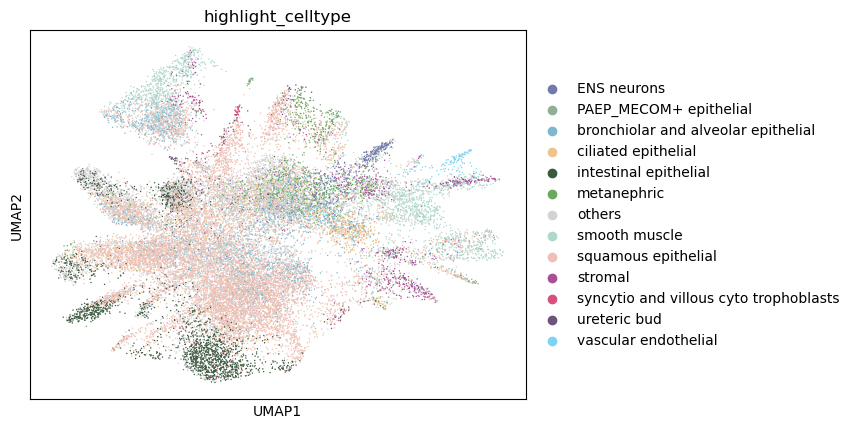

In [180]:
sc.pl.umap(adata_diff, color='highlight_celltype')

/home/wergillius/.conda/envs/GenDiff/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


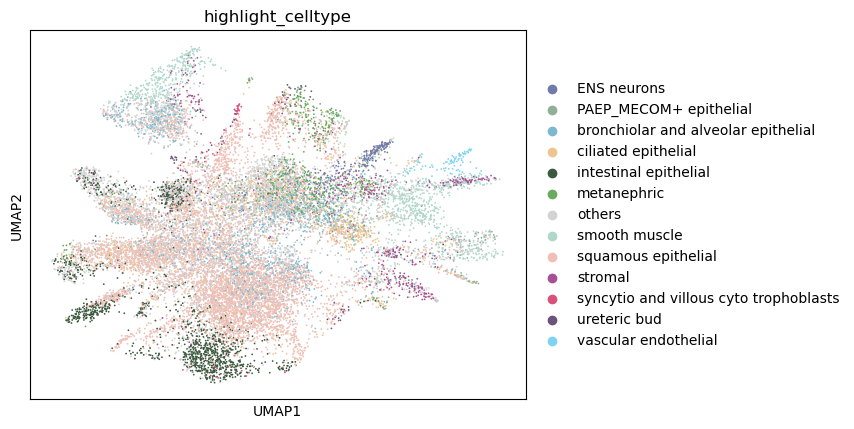

In [ ]:
sc.pl.umap(adata_filter, color='highlight_celltype')

In [8]:
from scipy.sparse.csgraph import dijkstra

In [4]:
adata_diff

AnnData object with n_obs × n_vars = 28825 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'batch_colors', 'diffmap_evals', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap', 'unique_token_dict'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
adata_filter

AnnData object with n_obs × n_vars = 18829 × 4806
    obs: 'TF', 'batch', 'louvain', 'n_counts', 'n_genes', 'percent_mito', 'dpt_pseudotime', 'discrete_time', 'split', 'Depth_from_root'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'KNN2', 'KNN_', 'batch_colors', 'diffmap_evals', 'hvg', 'iroot', 'louvain', 'louvain_colors', 'neighbors', 'pca', 'umap', 'unique_token_dict'
    obsm: 'X_diffmap', 'X_pca', 'X_pca_harmony', 'X_umap'
    varm: 'PCs'
    obsp: 'KNN2_connectivities', 'KNN2_distances', 'KNN__connectivities', 'KNN__distances', 'connectivities', 'distances'

In [10]:
iroot = adata_filter.uns['iroot']

In [11]:
adata_filter.uns['neighbors']['rp_forest'].keys()

dict_keys(['children', 'hyperplanes', 'indices', 'offsets'])

In [15]:
sc.pp.neighbors(adata_filter, n_neighbors=15, n_pcs=50, use_rep='X_pca_harmony', key_added='KNN_', knn=True)
sc.pp.neighbors(adata_filter, n_neighbors=30, n_pcs=50, use_rep='X_pca_harmony', key_added='KNN2', knn=True)

binary_adjacency = adata_filter.obsp['KNN__distances'].A !=0
n_degree = dijkstra(csgraph = binary_adjacency, indices = [iroot])

n_degree2 = dijkstra(csgraph = adata_filter.obsp['KNN2_distances'].A != 0, indices = [iroot])
np.isinf(n_degree).sum(), np.isinf(n_degree2).sum()

In [19]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

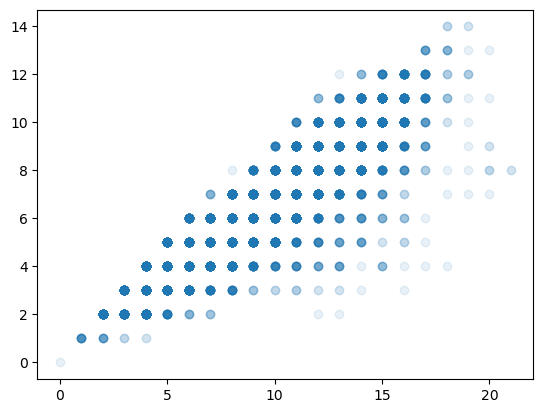

In [20]:
plt.scatter(n_degree, n_degree2, alpha=0.1)

In [63]:
idx = np.logical_not(np.logical_or(np.isinf(n_degree), np.isinf(n_degree2)))
lr = LinearRegression().fit(n_degree2[idx].reshape(-1, 1), n_degree[idx].reshape(-1, 1))

lr.coef_, lr.intercept_

(array([[1.41460299]]), array([0.03223859]))

In [64]:
complement = np.logical_and(np.isinf(n_degree), ~np.isinf(n_degree2))
filed = lr.predict(n_degree2[complement].reshape(-1,1)).astype(int)
n_degree[complement] = filed.flatten()

In [65]:
np.sum(np.isinf(n_degree)), np.sum(complement)

(553, 1310)

In [70]:
max_degree = n_degree[~np.isinf(n_degree)].max()
n_degree[np.isinf(n_degree)] = max_degree

max_degree, np.sum(np.isinf(n_degree))

(24.0, 0)

In [92]:
np.sum(adata_filter.obs['split'] == 'val')

1881

In [75]:
adata_filter.obs['Depth_from_root'] = n_degree[0]

In [94]:
np.isinf(n_degree[0]).sum()

0

In [36]:
root_cb = adata_filter.obs_names[adata_filter.uns['iroot']]
adata_filter.obs.loc[root_cb, 'Depth_from_root'] = 1

In [38]:
adata_filter.obs.loc[root_cb, 'Depth_from_root']

1.0

In [ ]:
from scipy.sparse.csgraph import dijkstra

k = adata_diff.uns['neighbors']['params']['n_neighbors']
sc.pp.neighbors(adata_diff, n_neighbors=k, knn=True, key_added="KNN")

degree = dijkstra(adata_diff.obsp['KNN_distances'], indices=adata_diff.uns['iroot'],
            unweighted=True, limit=1000,
            return_predecessors=False)

n_max = degree[~np.isinf(degree)].max()
print(np.isinf(degree).sum())
print(n_max)

imputed_degree = np.where(np.isinf(degree), n_max+1, degree)

adata_diff.obs['Depth_from_root'] = imputed_degree

In [39]:
adata_filter.write_h5ad(f"{main_dir}/data/TFAtlas/TFAtlas_filtered_diff.h5ad")
adata_diff.write_h5ad(f"{main_dir}/data/TFAtlas/GSE217460_210322_TFAtlas_differentiated.h5ad")